In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

%matplotlib inline

sns.set_theme(style="whitegrid")

In [13]:
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print(path)
os.listdir(path)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
/kaggle/input/superstore-dataset-final


['Sample - Superstore.csv']

In [17]:
file_path = os.path.join(path, "Sample - Superstore.csv")
df = pd.read_csv(file_path, encoding="latin1")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [21]:

print(f"jumalh baris : {df.shape[0]}")
print(f"jumalh kolom : {df.shape[1]}")

df.info()

jumalh baris : 9994
jumalh kolom : 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales         

In [22]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [25]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [26]:
df.duplicated().sum()

np.int64(0)

In [30]:
df['Order Date'] = pd.to_datetime(df["Order Date"])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [32]:
## Year Column
df["Year"] = df["Order Date"].dt.year

## Month Column
df["Month"] = df["Order Date"].dt.month

## Quarter Column
df["Quarter"] = df["Order Date"].dt.quarter

## Day Column
df["Day"] = df["Order Date"].dt.day

## Profit Margin Column
df["Profit Margin"] = (df['Profit'] / df['Sales']) * 100

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Day,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4,8,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4,8,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2,12,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4,11,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4,11,11.25


In [51]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer Name"].nunique()

print(f"Total Sales : ${total_sales:,.2f}")
print(f"total_profit : ${total_profit:,.2f}")
print(f"total_orders : {total_orders}")
print(f"total_customers : {total_customers}")

Total Sales : $2,297,200.86
total_profit : $286,397.02
total_orders : 5009
total_customers : 793


## **Most Profitable Region**

In [42]:
region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

region_profit

,Region,Profit
0,West,108418.4489
1,East,91522.7800
2,South,46749.4303
3,Central,39706.3625


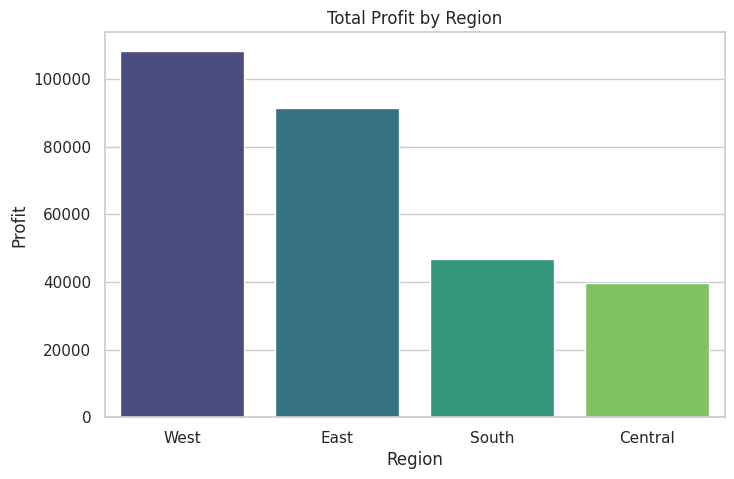

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=region_profit,
    x="Region",
    y="Profit",
    hue="Region",
    palette="viridis",
    legend=False
)

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

# **Most Profitable Products**

In [44]:
top_product = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top_product

,Product Name,Profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
5,Ativa V4110MDD Micro-Cut Shredder,3772.9461
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.2820
8,Ibico EPK-21 Electric Binding System,3345.2823
9,Zebra ZM400 Thermal Label Printer,3343.5360


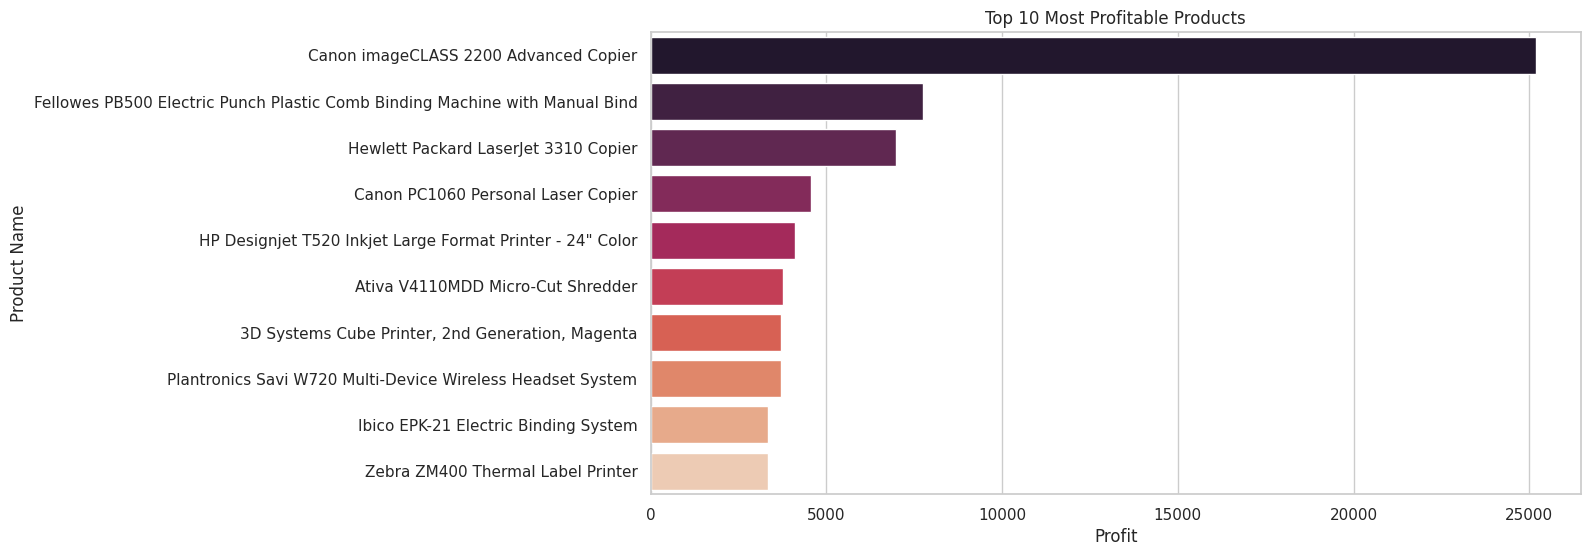

In [45]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_product,
    y="Product Name",
    x="Profit",
    hue="Product Name",
    palette="rocket",
    legend=False
)

plt.title("Top 10 Most Profitable Products")
plt.show()

# **Most Loyal Customers**

In [46]:
loyal_customer = (
    df.groupby("Customer Name")["Order ID"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

loyal_customer

,Customer Name,Order ID
0,Emily Phan,17
1,Sally Hughsby,13
2,Noel Staavos,13
3,Patrick Gardner,13
4,Zuschuss Carroll,13
5,Joel Eaton,13
6,Erin Ashbrook,13
7,Chloris Kastensmidt,13
8,Suzanne McNair,12
9,Rick Bensley,12


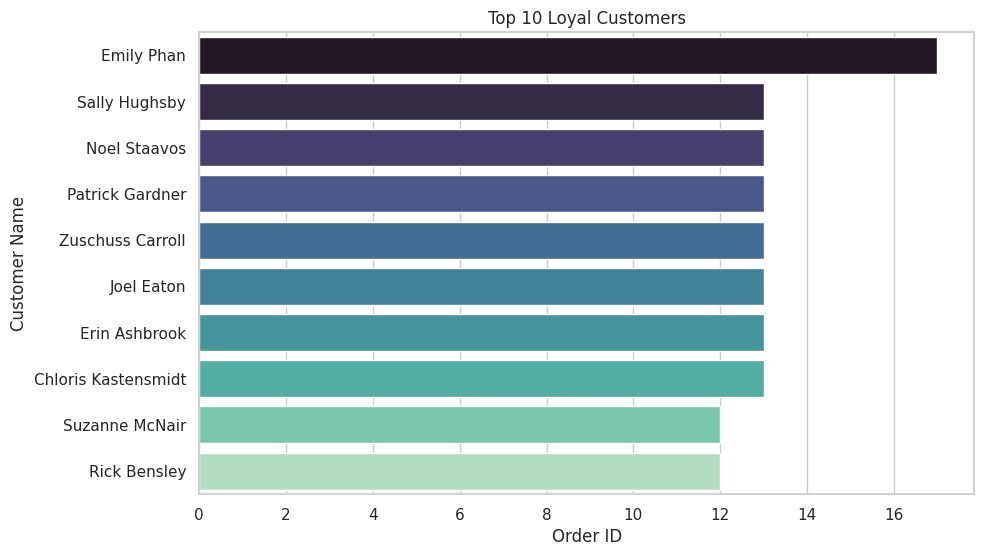

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=loyal_customer,
    y="Customer Name",
    x="Order ID",
    hue="Customer Name",
    palette="mako",
    legend=False
)

plt.title("Top 10 Loyal Customers")
plt.show()

# **Do Discounts Increase Profits?**

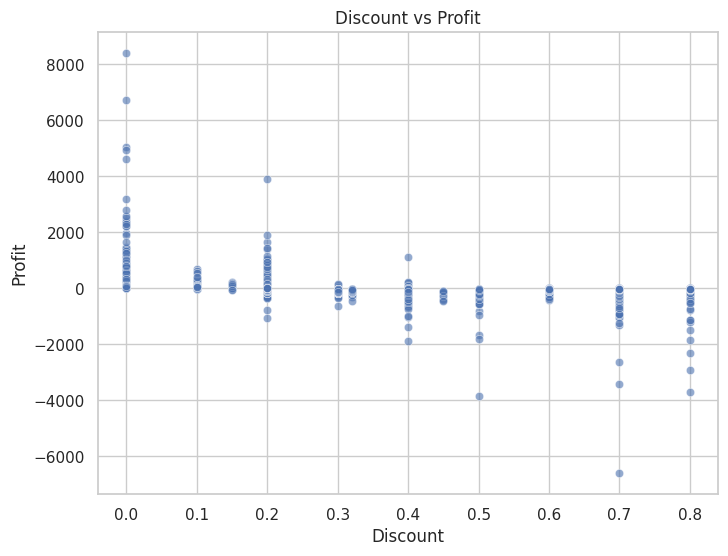

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    alpha=0.6
)

plt.title("Discount vs Profit")
plt.show()

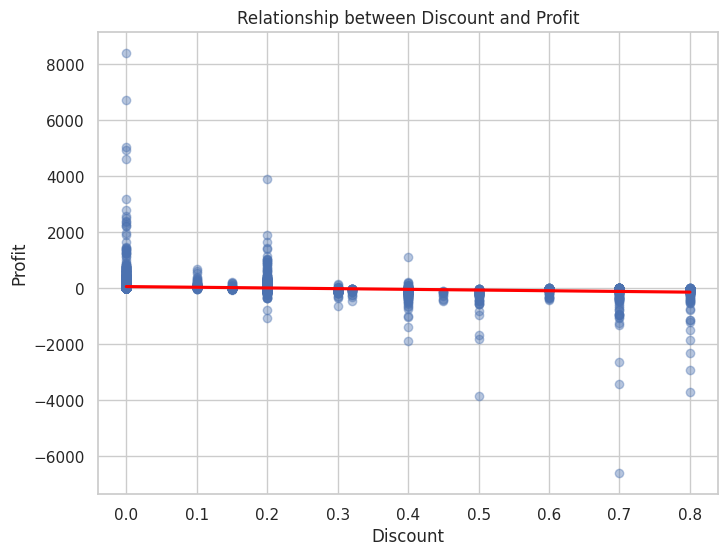

In [49]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Discount",
    y="Profit",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.title("Relationship between Discount and Profit")
plt.show()

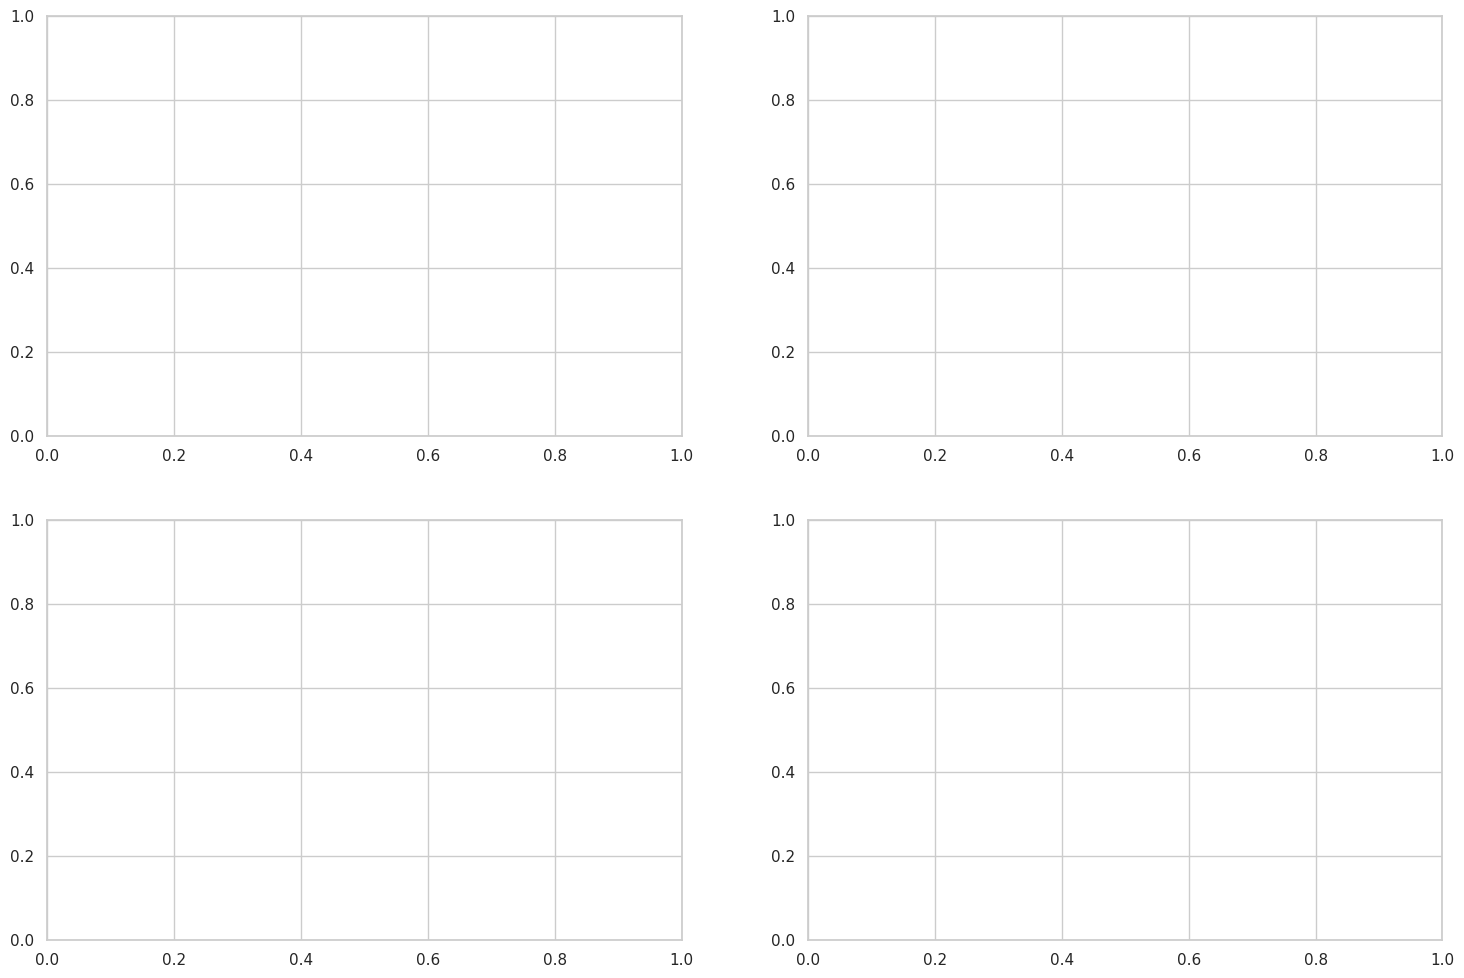

In [50]:
fig = plt.figure(figsize=(18,12))

gs = fig.add_gridspec(2,2)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])

## **DASHBOARD**

/tmp/ipykernel_576/3990428838.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_profit, x="Region", y="Profit", palette="Blues_r", ax=ax1)
/tmp/ipykernel_576/3990428838.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_profit, x="Category", y="Profit", palette="Greens_r", ax=ax3)
/tmp/ipykernel_576/3990428838.py:198: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_product, y="Short_Name", x="Profit", palette="Purples_r", ax=ax5)
/tmp/ipykernel_576/3990428838.py:218: FutureWarning: 

Passing `palette` 

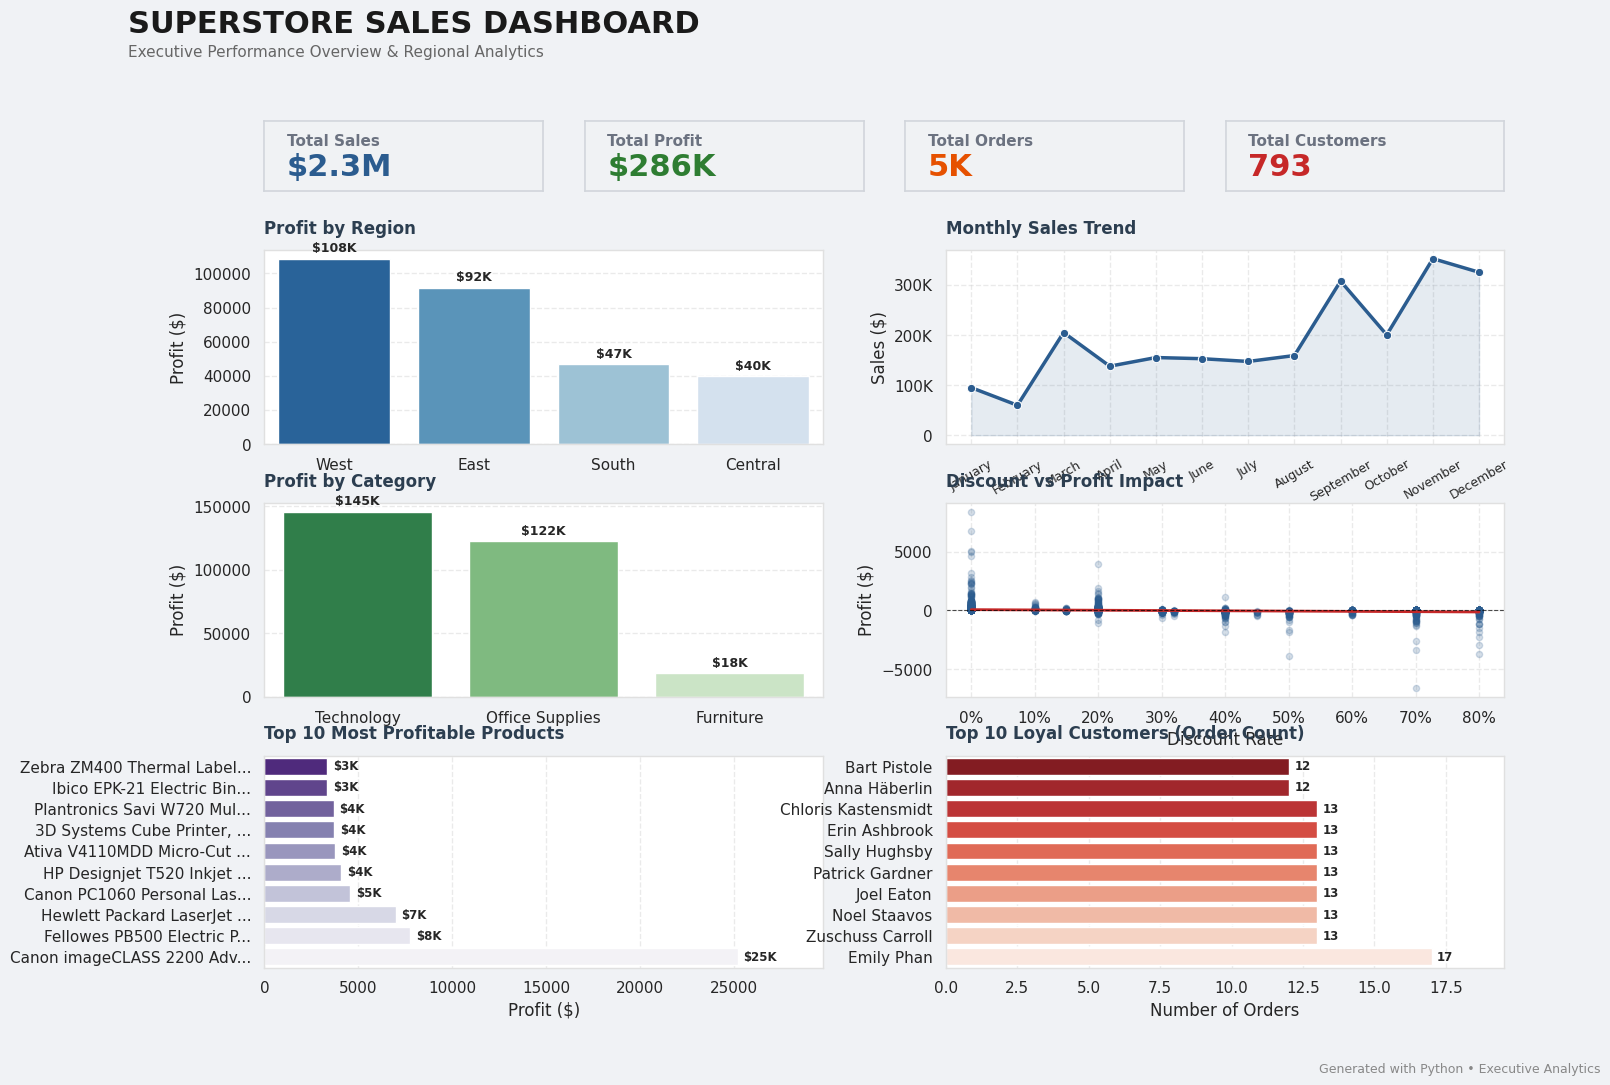

In [68]:
from matplotlib.gridspec import GridSpec
import matplotlib.patches as patches

# ==========================================================
# SETUP & DATA PREPARATION (DUMMY SETUP / ADJUST FOR YOUR DF)
# ==========================================================
# Pastikan kolom tanggal berformat datetime
if "Order Date" in df.columns:
    df["Order Date"] = pd.to_datetime(df["Order Date"])
    df["Month"] = df["Order Date"].dt.strftime("%B")

# Pre-aggregations
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

monthly_sales = df.groupby("Month", as_index=False)["Sales"].sum()
monthly_sales["Month"] = pd.Categorical(monthly_sales["Month"], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values("Month").dropna()

region_profit = df.groupby("Region", as_index=False)["Profit"].sum().sort_values("Profit", ascending=False)
category_profit = df.groupby("Category", as_index=False)["Profit"].sum().sort_values("Profit", ascending=False)

top_product = df.groupby("Product Name", as_index=False)["Profit"].sum().nlargest(10, "Profit").sort_values("Profit", ascending=True)
# Truncate product names if too long
top_product["Short_Name"] = top_product["Product Name"].apply(lambda x: x[:25] + "..." if len(x) > 25 else x)

loyal_customer = df.groupby("Customer Name", as_index=False)["Order ID"].nunique().nlargest(10, "Order ID").sort_values("Order ID", ascending=True)

# KPI Metrics
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer Name"].nunique()

# Helper function format K/M
def format_number(val, prefix=""):
    if abs(val) >= 1_000_000:
        return f"{prefix}{val/1_000_000:.1f}M"
    elif abs(val) >= 1_000:
        return f"{prefix}{val/1_000:.0f}K"
    else:
        return f"{prefix}{val:.0f}"

# ==========================================================
# DASHBOARD STYLE
# ==========================================================
sns.set_theme(style="white")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlelocation"] = "left"

BLUE = "#2B5C8F"
GREEN = "#2E7D32"
ORANGE = "#E65100"
RED = "#C62828"
BG_COLOR = "#F0F2F5"

# ==========================================================
# FIGURE LAYOUT
# ==========================================================
fig = plt.figure(figsize=(16, 11), facecolor=BG_COLOR)

gs = GridSpec(
    4, 2,
    figure=fig,
    height_ratios=[0.4, 1.1, 1.1, 1.2],
    hspace=0.35,
    wspace=0.22
)

# Header Title
fig.text(0.04, 0.96, "SUPERSTORE SALES DASHBOARD", fontsize=22, fontweight="bold", color="#1A1A1A")
fig.text(0.04, 0.938, "Executive Performance Overview & Regional Analytics", fontsize=11, color="#666666")

# Helper UI: Custom Card Background with Shadow
def apply_card_style(ax, title=""):
    ax.set_facecolor("white")
    if title:
        ax.set_title(title, pad=12, color="#2C3E50")

    # Border Tipis
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#E0E0E0")
        spine.set_linewidth(1)

    ax.grid(True, linestyle="--", alpha=0.4, color="#CCCCCC")

# ==========================================================
# KPI CARDS (Sub-Grid)
# ==========================================================
gs_kpi = gs[0, :].subgridspec(1, 4, wspace=0.15)

kpis = [
    ("Total Sales", format_number(total_sales, "$"), BLUE),
    ("Total Profit", format_number(total_profit, "$"), GREEN),
    ("Total Orders", format_number(total_orders), ORANGE),
    ("Total Customers", format_number(total_customers), RED)
]

for i, (title, val, color) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs_kpi[0, i])
    ax_kpi.set_facecolor("white")

    # Shadow Box Effect Behind Card
    shadow = patches.Rectangle((0, 0), 1, 1, transform=ax_kpi.transAxes,
                               facecolor="#D0D5DD", alpha=0.3, clip_on=False)
    ax_kpi.add_patch(shadow)

    # Card Border
    for spine in ax_kpi.spines.values():
        spine.set_visible(True)
        spine.set_color("#D1D5DB")
        spine.set_linewidth(1.2)

    ax_kpi.set_xticks([])
    ax_kpi.set_yticks([])

    # KPI Text
    ax_kpi.text(0.08, 0.65, title, fontsize=11, color="#6B7280", fontweight="bold")
    ax_kpi.text(0.08, 0.22, val, fontsize=22, fontweight="bold", color=color)

# ==========================================================
# GRAPH 1 : PROFIT BY REGION (Gradasi Visual)
# ==========================================================
ax1 = fig.add_subplot(gs[1, 0])
apply_card_style(ax1, "Profit by Region")

# Memakai Palette Gradasi Blues
sns.barplot(data=region_profit, x="Region", y="Profit", palette="Blues_r", ax=ax1)
ax1.set_xlabel("")
ax1.set_ylabel("Profit ($)")

for p in ax1.patches:
    height = p.get_height()
    if height != 0:
        ax1.annotate(format_number(height, "$"),
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                    textcoords='offset points', fontweight="bold")

# ==========================================================
# GRAPH 2 : MONTHLY SALES TREND
# ==========================================================
ax2 = fig.add_subplot(gs[1, 1])
apply_card_style(ax2, "Monthly Sales Trend")

sns.lineplot(data=monthly_sales, x="Month", y="Sales", marker="o", markersize=6,
             linewidth=2.5, color=BLUE, ax=ax2)

ax2.fill_between(range(len(monthly_sales)), monthly_sales["Sales"], color=BLUE, alpha=0.12)
ax2.set_xlabel("")
ax2.set_ylabel("Sales ($)")
ax2.tick_params(axis="x", rotation=30, labelsize=9)

# Format Sumbu Y ke K
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: format_number(x)))

# ==========================================================
# GRAPH 3 : PROFIT BY CATEGORY
# ==========================================================
ax3 = fig.add_subplot(gs[2, 0])
apply_card_style(ax3, "Profit by Category")

sns.barplot(data=category_profit, x="Category", y="Profit", palette="Greens_r", ax=ax3)
ax3.set_xlabel("")
ax3.set_ylabel("Profit ($)")

for p in ax3.patches:
    height = p.get_height()
    if height != 0:
        ax3.annotate(format_number(height, "$"),
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                    textcoords='offset points', fontweight="bold")

# ==========================================================
# GRAPH 4 : DISCOUNT VS PROFIT
# ==========================================================
ax4 = fig.add_subplot(gs[2, 1])
apply_card_style(ax4, "Discount vs Profit Impact")

sns.regplot(data=df, x="Discount", y="Profit", scatter_kws={"alpha":0.2, "s":20, "color":BLUE},
            line_kws={"color":RED, "linewidth":2}, ax=ax4)

ax4.set_xlabel("Discount Rate")
ax4.set_ylabel("Profit ($)")
ax4.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x*100)}%'))

# ==========================================================
# GRAPH 5 : TOP 10 PROFITABLE PRODUCTS (Truncated Names)
# ==========================================================
ax5 = fig.add_subplot(gs[3, 0])
apply_card_style(ax5, "Top 10 Most Profitable Products")

sns.barplot(data=top_product, y="Short_Name", x="Profit", palette="Purples_r", ax=ax5)
ax5.set_xlabel("Profit ($)")
ax5.set_ylabel("")

for p in ax5.patches:
    width = p.get_width()
    ax5.annotate(format_number(width, "$"),
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=8.5, xytext=(4, 0),
                textcoords='offset points', fontweight="bold")

# Expand limits agar angka tidak terpotong tepi
ax5.set_xlim(0, top_product["Profit"].max() * 1.18)

# ==========================================================
# GRAPH 6 : TOP 10 LOYAL CUSTOMERS
# ==========================================================
ax6 = fig.add_subplot(gs[3, 1])
apply_card_style(ax6, "Top 10 Loyal Customers (Order Count)")

sns.barplot(data=loyal_customer, y="Customer Name", x="Order ID", palette="Reds_r", ax=ax6)
ax6.set_xlabel("Number of Orders")
ax6.set_ylabel("")

for p in ax6.patches:
    width = p.get_width()
    ax6.annotate(f"{int(width)}",
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=8.5, xytext=(4, 0),
                textcoords='offset points', fontweight="bold")

ax6.set_xlim(0, loyal_customer["Order ID"].max() * 1.15)

# ==========================================================
# FOOTER & ADJUSTMENT
# ==========================================================
fig.text(0.96, 0.015, "Generated with Python • Executive Analytics", ha="right", fontsize=9, color="#888888")

# Mengatur margin agar seluruh area terisi padat tanpa banyak ruang kosong
plt.tight_layout(rect=[0.02, 0.02, 0.98, 0.93])

plt.show()